In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

In [22]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [23]:
SEED = 42
np.random.seed(SEED)

In [24]:
csv_path = (r'C:\Users\CAMILLE.KOENIG\Downloads\Features ML2\features\features_V2.csv')
df = pd.read_csv(csv_path)
print("Shape :", df.shape)
print("Colonnes (5 premières) :", df.columns[:5].tolist())
print("Genres :", df["genre_top"].value_counts().to_dict())

# Vérifier où sont les NaN
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Colonnes avec NaN : {len(missing)}")
print(f"Total NaN : {df.isnull().sum().sum()}")
print(missing)

# Ne garder que les colonnes numériques comme features
meta_cols = ["track_id", "genre_top", "artist_name", "set_split"]
feature_cols = [c for c in df.select_dtypes(include="number").columns if c not in meta_cols]

print(f"\nNombre de colonnes features numériques : {len(feature_cols)}")

# Remplacer les NaN par la médiane de chaque colonne feature
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Vérification
assert df[feature_cols].isnull().sum().sum() == 0, "NaN restants après imputation !"
print("Aucun NaN restant dans les features")

Shape : (7994, 362)
Colonnes (5 premières) : ['track_id', 'genre_top', 'genres', 'genres_decoded', 'n_subgenres']
Genres : {'Pop': 1000, 'Folk': 1000, 'Instrumental': 1000, 'International': 1000, 'Rock': 999, 'Experimental': 999, 'Electronic': 999, 'Hip-Hop': 997}
Colonnes avec NaN : 100
Total NaN : 104
chroma_stft_08_kurtosis    2
chroma_stft_08_skew        2
chroma_stft_01_skew        2
chroma_stft_01_kurtosis    2
mfcc_03_skew               1
                          ..
tonnetz_05_kurtosis        1
tonnetz_06_skew            1
tonnetz_06_kurtosis        1
zcr_01_skew                1
zcr_01_kurtosis            1
Length: 100, dtype: int64

Nombre de colonnes features numériques : 356
Aucun NaN restant dans les features


In [25]:
NON_FEATURE_COLS = [
    "track_id", "genre_top", "artist_name", "genres_decoded",
    "genres", "n_subgenres", "mismatch", "track_title",
    "year", "duration", "bit_rate"
]

# Liste des colonnes qui ne sont pas des features audios

X = df.drop(columns=NON_FEATURE_COLS)
y = df["genre_top"]
groups = df["artist_name"]

# Créations de trois objects distincts
# x contient les features audios
# y est la prédiction à faire (le genre)
# group contient les artistes qu'on donne au splitter pour éviter les fuites de données

print("X shape :", X.shape)
print("y distribution :\n", y.value_counts())
print("Nombre d'artistes uniques :", groups.nunique())

X shape : (7994, 351)
y distribution :
 genre_top
Pop              1000
Folk             1000
Instrumental     1000
International    1000
Rock              999
Experimental      999
Electronic        999
Hip-Hop           997
Name: count, dtype: int64
Nombre d'artistes uniques : 2304


In [26]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
# création du splitter
# 1 seul split (80% train, 20% test), avec un random state pour la reproductibilité

train_idx, test_idx = next(gss.split(X, y, groups=groups))
# on génère les indices de train et test à partir du splitter
# le splitter s'assure que les artistes ne sont pas partagés entre train et test

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
# extraction des données

print(f"\nTrain : {len(X_train)} pistes — Test : {len(X_test)} pistes")
print("Distribution train :", y_train.value_counts())
print()
print("Distribution test  :", y_test.value_counts())
# vérification de la répartition des classes dans les sets train et test

print()
artists_train = set(groups.iloc[train_idx])
artists_test  = set(groups.iloc[test_idx])
overlap = artists_train & artists_test
assert len(overlap) == 0, f"Overlap artistes train/test détecté : {overlap}"
print("Group split validé, aucun artiste en commun entre train et test")


Train : 6477 pistes — Test : 1517 pistes
Distribution train : genre_top
Folk             881
Pop              872
Instrumental     830
Rock             829
Experimental     800
Hip-Hop          764
International    751
Electronic       750
Name: count, dtype: int64

Distribution test  : genre_top
International    249
Electronic       249
Hip-Hop          233
Experimental     199
Instrumental     170
Rock             170
Pop              128
Folk             119
Name: count, dtype: int64

Group split validé, aucun artiste en commun entre train et test


In [27]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Régression logitique
lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    C=1.0,
    solver="lbfgs",
)
# lbfgs est un algorithme d'optimisation efficace pour les problèmes de classification multiclasse

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
# entrainement et prédiction avec la régression logistique

f1_lr = f1_score(y_test, y_pred_lr, average="macro")
acc_lr = accuracy_score(y_test, y_pred_lr)
# calcul des deux métriques

print(f"F1 macro : {f1_lr:.4f}")
print(f"Accuracy : {acc_lr:.4f}")
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_lr))
# Affichage des résultats de la régression logistique

F1 macro : 0.4506
Accuracy : 0.4628
Rapport détaillé :
               precision    recall  f1-score   support

   Electronic       0.48      0.54      0.50       249
 Experimental       0.45      0.37      0.40       199
         Folk       0.40      0.52      0.45       119
      Hip-Hop       0.61      0.52      0.56       233
 Instrumental       0.37      0.43      0.40       170
International       0.58      0.46      0.51       249
          Pop       0.22      0.27      0.24       128
         Rock       0.54      0.53      0.53       170

     accuracy                           0.46      1517
    macro avg       0.45      0.45      0.45      1517
 weighted avg       0.48      0.46      0.47      1517



In [29]:
# Modèle fort : Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

f1_rf  = f1_score(y_test, y_pred_rf, average="macro")
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"F1 macro : {f1_rf:.4f}")
print(f"Accuracy : {acc_rf:.4f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_rf))

F1 macro : 0.4586
Accuracy : 0.4641

Rapport détaillé :
               precision    recall  f1-score   support

   Electronic       0.49      0.46      0.47       249
 Experimental       0.53      0.35      0.42       199
         Folk       0.46      0.68      0.55       119
      Hip-Hop       0.59      0.54      0.56       233
 Instrumental       0.40      0.52      0.45       170
International       0.57      0.38      0.46       249
          Pop       0.16      0.23      0.18       128
         Rock       0.55      0.60      0.57       170

     accuracy                           0.46      1517
    macro avg       0.47      0.47      0.46      1517
 weighted avg       0.49      0.46      0.47      1517



In [30]:
# Comparaison des modèles
results = pd.DataFrame({
    "Modèle"   : ["Logistic Regression", "Random Forest"],
    "F1 macro" : [round(f1_lr, 4),  round(f1_rf, 4)],
    "Accuracy" : [round(acc_lr, 4), round(acc_rf, 4)],
})
print("\n=== TABLEAU COMPARATIF ===")
print(results.to_string(index=False))


=== TABLEAU COMPARATIF ===
             Modèle  F1 macro  Accuracy
Logistic Regression    0.4506    0.4628
      Random Forest    0.4586    0.4641


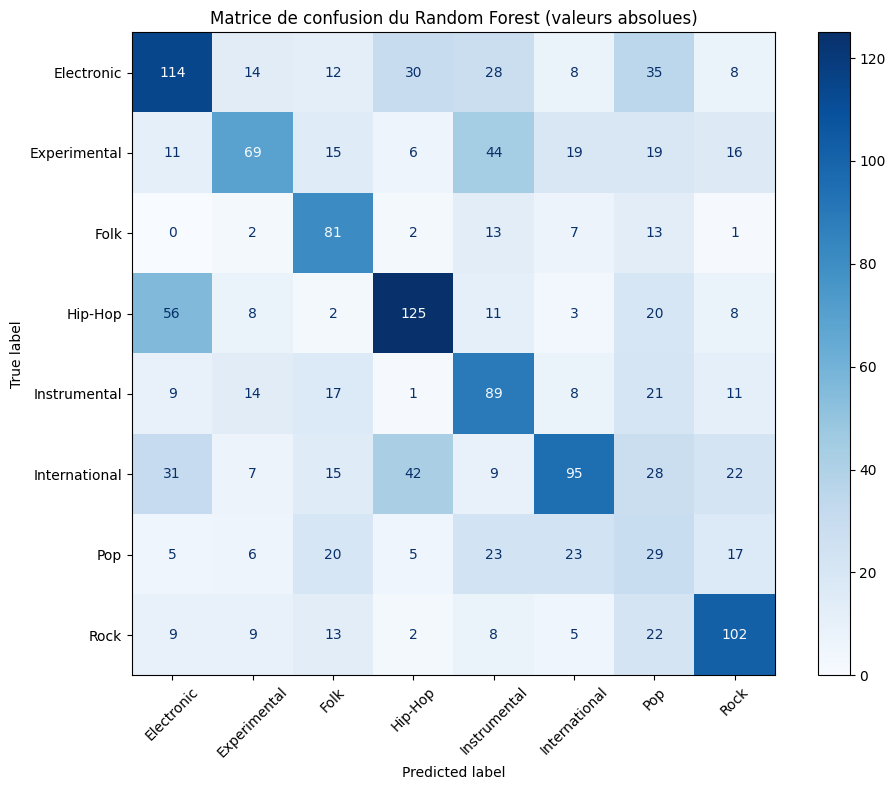

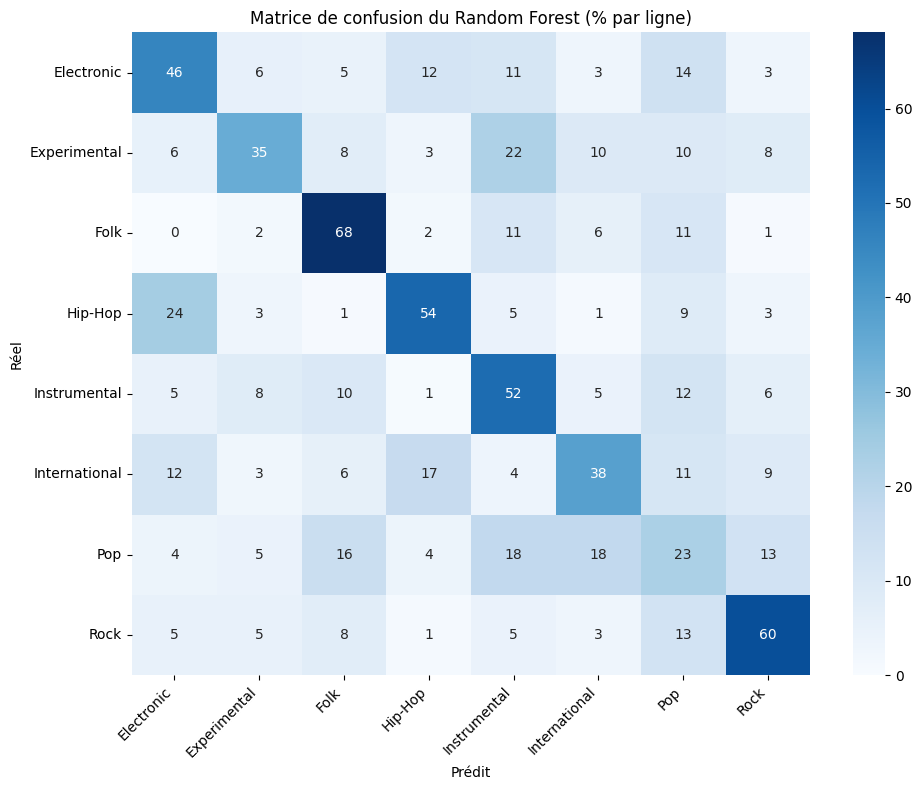

In [31]:
# Martrice de confusion pour la régression logistique
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
# calcule la matrice en valeurs absolue
# puis normalisation en pourcentage par ligne
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Matrice de confusion du Random Forest (valeurs absolues)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".0f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues",
    ax=ax,
)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion du Random Forest (% par ligne)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

== ANALYSE DES ERREURS ==
        Genre  Mismatch_%  Recall    F1
      Hip-Hop        12.4   0.536 0.561
         Folk        22.8   0.681 0.551
 Instrumental        36.3   0.524 0.451
 Experimental        41.5   0.347 0.421
          Pop        42.6   0.227 0.184
   Electronic        47.1   0.458 0.471
         Rock        63.9   0.600 0.575
International        68.0   0.382 0.456


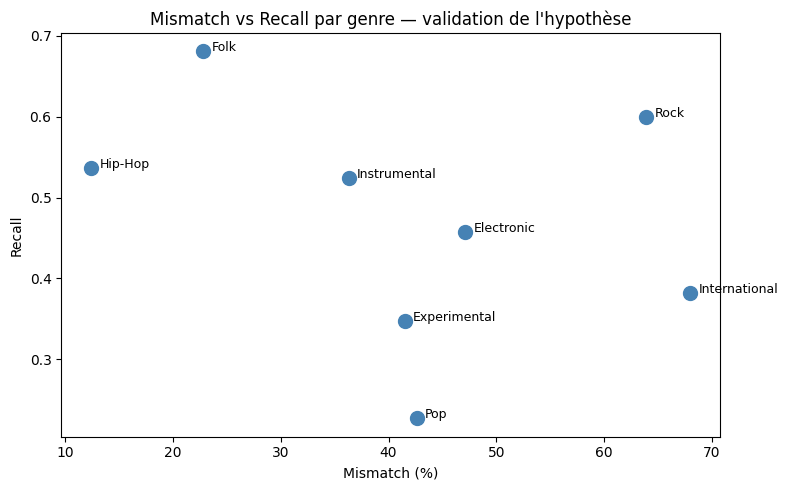

In [ ]:
# Analyse des erreurs
report = classification_report(y_test, y_pred_rf, output_dict=True)
# Affichage du rapport de classification sous forme de dictionnaire pour une analyse plus facile
mismatch = {
    "Hip-Hop"       : 12.4,
    "Folk"          : 22.8,
    "Instrumental"  : 36.3,
    "Experimental"  : 41.5,
    "Pop"           : 42.6,
    "Electronic"    : 47.1,
    "Rock"          : 63.9,
    "International" : 68.0,
}
# valeurs de mismatch calculées dans l'EDA
analysis = pd.DataFrame({
    "Genre"       : list(mismatch.keys()),
    "Mismatch_%"  : list(mismatch.values()),
    "Recall"      : [round(report[g]["recall"], 3) for g in mismatch.keys()],
    "F1"          : [round(report[g]["f1-score"], 3) for g in mismatch.keys()],
}).sort_values("Mismatch_%")
# Tableau entre les valeurs de mismatch et les performances du modèle par genre
print("== ANALYSE DES ERREURS ==")
print(analysis.to_string(index=False))
# Affichage du tableau d'analyse des erreurs
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(analysis["Mismatch_%"], analysis["Recall"], s=100, color="steelblue")
for _, row in analysis.iterrows():
    ax.annotate(row["Genre"], (row["Mismatch_%"], row["Recall"]),
                textcoords="offset points", xytext=(6, 0), fontsize=9)
ax.set_xlabel("Mismatch (%)")
ax.set_ylabel("Recall")
ax.set_title("Mismatch vs Recall par genre")
plt.tight_layout()
plt.show()
# Plus le mismatch est élevé, moins le modèle performe

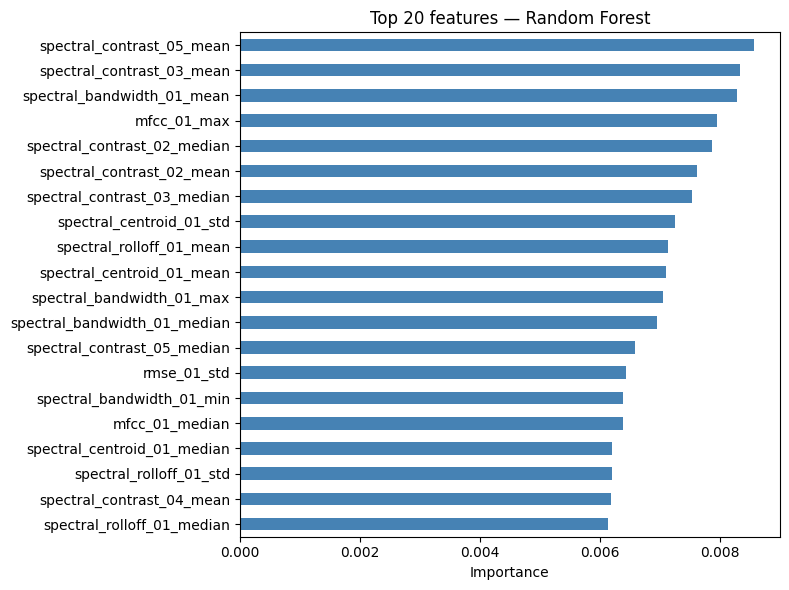

In [33]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)
# Affichage des 20 features les plus importantes du Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 features — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()